In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [7]:
# --- Dades del sistema ---
m = 0.02   # kg
c = 1.25   # Ns/m
k = 5500   # N/m

In [8]:
# --- Espai d'estat ---
A = np.array([[0, 1],
              [-k/m, -c/m]])

B = np.array([[0],
              [1/m]])

C = np.array([[k, 0]])   # output = k*x
D = np.array([[0]])

system = signal.StateSpace(A, B, C, D)

In [9]:
# --- Pols ---
p = np.linalg.eigvals(A)

omega_n = np.abs(p)
zeta = np.abs(np.real(p)) / np.abs(p)
omega_r = np.abs(np.imag(p))

print('\n' + '-'*60)
print(f"{'Paràmetre':>12} | {'Valor':>20}")
print('-'*60)

print(f"{'omega_n':>12} | {omega_n[0]:20.2f}  rad/s")
print(f"{'zeta':>12} | {zeta[0]:20.4f}")
print(f"{'omega_r':>12} | {omega_r[0]:20.2f}  rad/s")

print(f"{'poles':>12} |")
for pole in p:
    print(f"{'':>12} | {pole.real:8.2f} {pole.imag:+8.2f}j")

print('-'*60 + '\n')


------------------------------------------------------------
   Paràmetre |                Valor
------------------------------------------------------------
     omega_n |               524.40  rad/s
        zeta |               0.0596
     omega_r |               523.47  rad/s
       poles |
             |   -31.25  +523.47j
             |   -31.25  -523.47j
------------------------------------------------------------



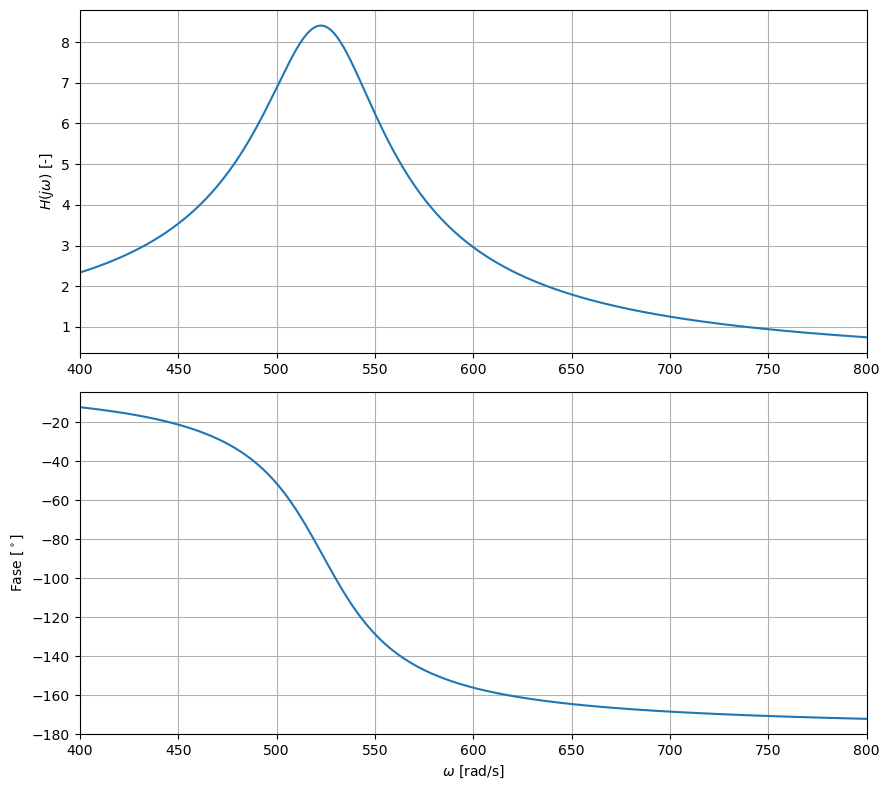

In [10]:
# --- Bode ---
w = np.linspace(400, 800, 1000)
w, mag, phase = signal.bode(system, w)

H = 10**(mag/20)  # magnitud de dB a absoluta

# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(9, 8))

axs[0].plot(w, H, color='tab:blue')
axs[0].set_ylabel(r"$H(j\omega)$ [-]")
axs[0].set_xlim([400, 800])
axs[0].grid()

axs[1].plot(w, phase, color='tab:blue')
axs[1].set_xlabel(r"$\omega$ [rad/s]")
axs[1].set_ylabel(r"Fase [$^\circ$]")
axs[1].set_xlim([400, 800])
axs[1].grid()

plt.tight_layout()
plt.show()